In [1]:
from time import time
import pandas as pd
import numpy as np
from collections import OrderedDict
import warnings

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import matplotlib.colors

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    AdaBoostClassifier, GradientBoostingClassifier,
    RandomForestClassifier, ExtraTreesClassifier
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC

from sklearn.preprocessing import StandardScaler

In [2]:
def apply_style():
    plt.rcParams.update({
        'font.size': 14,
        'axes.labelsize': 14,
        'axes.titlesize': 16,
        'xtick.labelsize': 14,
        'ytick.labelsize': 14,
        'legend.fontsize': 14,
        'lines.linewidth': 1.5,
        'lines.markersize': 4,
        'axes.linewidth': 1.5,
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'xtick.top': True,
        'ytick.right': True,
        'xtick.minor.visible': True,
        'ytick.minor.visible': True,
        'xtick.major.width': 1,
        'ytick.major.width': 1,
        'xtick.minor.width': 0.5,
        'ytick.minor.width': 0.5,
        'xtick.major.size': 4,
        'ytick.major.size': 4,
        'xtick.minor.size': 1.5,
        'ytick.minor.size': 1.5,
        'legend.frameon': False,
        'legend.handlelength': 2,
        'legend.handletextpad': 0.5,
        'figure.dpi': 100,
        'savefig.dpi': 600,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.02,
    })

apply_style()

In [3]:
def instantiate_model(model_name):
    model = model_name()
    return model

def fit_model(model, X_train, y_train):
    ti = time()
    model = instantiate_model(model)
    model.fit(X_train, y_train)
    fit_time = time() - ti
    return model, fit_time

def append_result_df(df, result_dict):
    df_result_appended = pd.concat([df, pd.DataFrame([result_dict])], ignore_index=True)
    return df_result_appended

def append_model_dict(dic, model_name, model):
    dic[model_name] = model
    return dic

def evaluate_model(model, X, y_act):
    y_pred = model.predict(X)
    acc = accuracy_score(y_act, y_pred)
    f1 = f1_score(y_act, y_pred, average="weighted", zero_division=0)
    precision = precision_score(y_act, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_act, y_pred, average="weighted", zero_division=0)
    return acc, f1, precision, recall

def fit_evaluate_model(model, model_name, X_train, y_train, X_val, y_val):
    model, fit_time = fit_model(model, X_train, y_train)
    acc_train, f1_train, prec_train, rec_train = evaluate_model(model, X_train, y_train)
    acc_val, f1_val, prec_val, rec_val = evaluate_model(model, X_val, y_val)
    result_dict = {
        'model_name': model_name,
        'model_name_pretty': type(model).__name__,
        'model_params': model.get_params(),
        'fit_time': fit_time,
        'acc_train': acc_train,
        'f1_train': f1_train,
        'precision_train': prec_train,
        'recall_train': rec_train,
        'acc_val': acc_val,
        'f1_val': f1_val,
        'precision_val': prec_val,
        'recall_val': rec_val,
    }
    return model, result_dict

In [4]:
df_train = pd.read_csv('classification_dataset_splits/app_train_split.csv')
df_test = pd.read_csv('classification_dataset_splits/app_test_split.csv')
df_val = pd.read_csv('classification_dataset_splits/app_val_split.csv')

In [5]:
df_train.head()

,UID,Chemical,Time,Na,Cu,Fe,Mn,Ni,P2O3ratio,Cat_Success,...,var_gordy_en_max,var_gordy_en_range,var_gordy_en_mode,var_mb_en_sum,var_mb_en_avg,var_mb_en_dev,var_mb_en_min,var_mb_en_max,var_mb_en_range,var_mb_en_mode
0,U00001,NaCuO2,12,1.0,1.0,0.0,0.0,0.0,-1.0,Unsuccessful,...,0.271435,0.000000,0.271435,0.103448,0.103448,0.000000,0.103448,0.103448,0.000000,0.103448
1,U00002,NaFeO2,12,1.0,0.0,1.0,0.0,0.0,-1.0,Unsuccessful,...,0.266255,0.000000,0.266255,0.063694,0.063694,0.000000,0.063694,0.063694,0.000000,0.063694
2,U00003,NaMnO2,12,1.0,0.0,0.0,1.0,0.0,0.8,Successful,...,0.254777,0.000000,0.254777,0.050955,0.050955,0.000000,0.050955,0.050955,0.000000,0.050955
3,U00004,NaNiO2,12,1.0,0.0,0.0,0.0,1.0,-1.0,Unsuccessful,...,0.306872,0.000000,0.306872,0.094595,0.094595,0.000000,0.094595,0.094595,0.000000,0.094595
4,U00006,NaCu0.5Mn0.5O2,12,1.0,0.5,0.0,0.5,0.0,1.0,Successful,...,0.298507,0.027073,0.271435,0.074112,0.074112,0.029336,0.044776,0.103448,0.058672,0.103448


In [6]:
df_train["Cat_Success"] = df_train["Cat_Success"].astype("category")
df_test["Cat_Success"] = df_test["Cat_Success"].astype("category")
df_val["Cat_Success"] = df_val["Cat_Success"].astype("category")

label_mapping = dict(enumerate(df_train["Cat_Success"].cat.categories))
print(label_mapping)

{0: 'Successful', 1: 'Unsuccessful'}


In [7]:
categories = df_train["Cat_Success"].cat.categories

df_train["Cat_Success"] = df_train["Cat_Success"].cat.set_categories(categories)
df_val["Cat_Success"]   = df_val["Cat_Success"].cat.set_categories(categories)
df_test["Cat_Success"]  = df_test["Cat_Success"].cat.set_categories(categories)

df_train["target"] = df_train["Cat_Success"].cat.codes
df_val["target"]   = df_val["Cat_Success"].cat.codes
df_test["target"]  = df_test["Cat_Success"].cat.codes

/tmp/ipykernel_59382/3185448588.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_train["target"] = df_train["Cat_Success"].cat.codes
/tmp/ipykernel_59382/3185448588.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_val["target"]   = df_val["Cat_Success"].cat.codes
/tmp/ipykernel_59382/3185448588.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To 

In [8]:
# Define which columns are your features (drop non-numeric / target cols)
feature_cols = [col for col in df_train.columns if col not in ['UID','Chemical','P2O3ratio','target', 'formula', 'Cat_Success']]

# Training
X_train = df_train[feature_cols].values
y_train = df_train['target'].values

# Validation
X_val = df_val[feature_cols].values
y_val = df_val['target'].values

# Test
X_test = df_test[feature_cols].values
y_test = df_test['target'].values

In [9]:
print(feature_cols)
print(X_train.shape)  # should be (n_samples, n_features)
print(y_train.shape)  # should be (n_samples,)
print(label_mapping)

['Time', 'Na', 'Cu', 'Fe', 'Mn', 'Ni', 'all_valence_s_avg', 'all_valence_s_dev', 'all_valence_s_mode', 'all_unfilled_valence_s_sum', 'all_unfilled_valence_s_avg', 'all_unfilled_valence_s_dev', 'all_unfilled_valence_s_mode', 'all_valence_p_avg', 'all_valence_p_dev', 'all_valence_p_mode', 'all_unfilled_valence_p_sum', 'all_unfilled_valence_p_avg', 'all_unfilled_valence_p_dev', 'all_unfilled_valence_p_mode', 'all_valence_d_sum', 'all_valence_d_avg', 'all_valence_d_dev', 'all_valence_d_max', 'all_valence_d_range', 'all_unfilled_valence_d_sum', 'all_unfilled_valence_d_avg', 'all_unfilled_valence_d_dev', 'all_unfilled_valence_d_min', 'all_unfilled_valence_d_range', 'all_unfilled_valence_f_sum', 'all_unfilled_valence_f_avg', 'all_unfilled_valence_f_dev', 'all_valence_total_sum', 'all_valence_total_avg', 'all_valence_total_dev', 'all_valence_total_max', 'all_valence_total_range', 'all_unfilled_valence_total_sum', 'all_unfilled_valence_total_avg', 'all_unfilled_valence_total_dev', 'all_unfilled

In [10]:
print(f"NaNs in X_train: {np.isnan(X_train).sum()}")
print(f"NaNs in X_val: {np.isnan(X_val).sum()}")

# To see which feature columns have NaNs
nan_cols = df_train[feature_cols].isnull().sum()
print(nan_cols[nan_cols > 0])

NaNs in X_train: 0
NaNs in X_val: 0
Series([], dtype: int64)


In [11]:
# from sklearn.preprocessing import StandardScaler
# from sklearn.preprocessing import normalize

# scaler = StandardScaler()

# X_train = scaler.fit_transform(X_train)
# X_val = scaler.transform(X_val)
# X_test = scaler.transform(X_test)

# X_train = normalize(X_train)
# X_val = normalize(X_val)
# X_test = normalize(X_test)

In [12]:
df_classics = pd.DataFrame(columns=[
    'model_name',
    'model_name_pretty',
    'model_params',
    'fit_time',
    'acc_train',
    'f1_train',
    'precision_train',
    'recall_train',
    'acc_val',
    'f1_val',
    'precision_val',
    'recall_val'
])

RANDOM_SEED = 20

classic_model_classes = OrderedDict({
    'dumc': DummyClassifier,
    'lr':   LogisticRegression,
    'abc':  AdaBoostClassifier,
    'gbc':  GradientBoostingClassifier,
    'rfc':  RandomForestClassifier,
    'etc':  ExtraTreesClassifier,
    'svc':  SVC,
    'lsvc': LinearSVC,
    'knc':  KNeighborsClassifier,
})

# Models with seeds and convergence fixes applied
classic_model_names = OrderedDict({
    'dumc': lambda: DummyClassifier(random_state=RANDOM_SEED),
    'lr':   lambda: LogisticRegression(random_state=RANDOM_SEED, max_iter=1000),
    'abc':  lambda: AdaBoostClassifier(random_state=RANDOM_SEED),
    'gbc':  lambda: GradientBoostingClassifier(random_state=RANDOM_SEED),
    'rfc':  lambda: RandomForestClassifier(random_state=RANDOM_SEED),
    'etc':  lambda: ExtraTreesClassifier(random_state=RANDOM_SEED),
    'svc':  lambda: SVC(random_state=RANDOM_SEED),
    'lsvc': lambda: LinearSVC(random_state=RANDOM_SEED, max_iter=5000),
    'knc':  lambda: KNeighborsClassifier(),  # no random_state needed
})

df_classics = pd.DataFrame()
classic_models = OrderedDict()

np.random.seed(RANDOM_SEED)

ti = time()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for model_name, model in classic_model_names.items():
        print(f'Now fitting and evaluating model {model_name}: {model}')
        model, result_dict = fit_evaluate_model(
            model, model_name, X_train, y_train, X_val, y_val
        )
        df_classics = append_result_df(df_classics, result_dict)
        classic_models = append_model_dict(classic_models, model_name, model)

dt = time() - ti
print(f'Finished fitting {len(classic_models)} models, total time: {dt:0.2f} s')

Now fitting and evaluating model dumc: <function <lambda> at 0x72dc341c3240>
Now fitting and evaluating model lr: <function <lambda> at 0x72dc341c0c20>
Now fitting and evaluating model abc: <function <lambda> at 0x72dc341c31a0>
Now fitting and evaluating model gbc: <function <lambda> at 0x72dc341c32e0>
Now fitting and evaluating model rfc: <function <lambda> at 0x72dc341c3420>
Now fitting and evaluating model etc: <function <lambda> at 0x72dc341c0cc0>
Now fitting and evaluating model svc: <function <lambda> at 0x72dc341c0ae0>
Now fitting and evaluating model lsvc: <function <lambda> at 0x72dc341c3600>
Now fitting and evaluating model knc: <function <lambda> at 0x72dc341c36a0>
Finished fitting 9 models, total time: 0.89 s


In [13]:
# Sort in order of increasing validation r2 score
df_classics = df_classics.sort_values('f1_val', ignore_index=True)
df_classics

,model_name,model_name_pretty,model_params,fit_time,acc_train,f1_train,precision_train,recall_train,acc_val,f1_val,precision_val,recall_val
0,dumc,DummyClassifier,"{'constant': None, 'random_state': 20, 'strate...",0.000954,0.726923,0.611975,0.528417,0.726923,0.625000,0.480769,0.390625,0.625000
1,lr,LogisticRegression,"{'C': 1.0, 'class_weight': None, 'dual': False...",0.077585,0.973077,0.972892,0.973038,0.973077,0.972222,0.971990,0.973404,0.972222
2,abc,AdaBoostClassifier,"{'estimator': None, 'learning_rate': 1.0, 'n_e...",0.092403,0.965385,0.964979,0.965496,0.965385,0.972222,0.971990,0.973404,0.972222
3,rfc,RandomForestClassifier,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...",0.064531,1.000000,1.000000,1.000000,1.000000,0.972222,0.971990,0.973404,0.972222
4,svc,SVC,"{'C': 1.0, 'break_ties': False, 'cache_size': ...",0.002842,0.961538,0.960577,0.963471,0.961538,0.972222,0.971990,0.973404,0.972222
5,etc,ExtraTreesClassifier,"{'bootstrap': False, 'ccp_alpha': 0.0, 'class_...",0.045073,1.000000,1.000000,1.000000,1.000000,0.972222,0.971990,0.973404,0.972222
6,lsvc,LinearSVC,"{'C': 1.0, 'class_weight': None, 'dual': 'auto...",0.106757,0.965385,0.964802,0.966063,0.965385,0.972222,0.971990,0.973404,0.972222
7,knc,KNeighborsClassifier,"{'algorithm': 'auto', 'leaf_size': 30, 'metric...",0.000722,0.961538,0.960577,0.963471,0.961538,0.972222,0.971990,0.973404,0.972222
8,gbc,GradientBoostingClassifier,"{'ccp_alpha': 0.0, 'criterion': 'deprecated', ...",0.290390,1.000000,1.000000,1.000000,1.000000,0.986111,0.986056,0.986413,0.986111


In [14]:
# Find the best-performing model that we have tested
best_row = df_classics.iloc[-4, :].copy()

# Get the model type and model parameters
model_name = best_row['model_name']
model_params = best_row['model_params']

# Instantiate the model again using the parameters
model = classic_model_classes[model_name](**model_params)
print(model)
print(model.get_params())

ExtraTreesClassifier(random_state=20)
{'bootstrap': False, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 20, 'verbose': 0, 'warm_start': False}


In [15]:
# Concatenate the train and validation datasets together
X_train_final = np.concatenate((X_train, X_val), axis=0)
y_train_final = np.concatenate((y_train, y_val), axis=0)

print(X_train_final.shape)

ti = time()

model.fit(X_train_final, y_train_final)

dt = time() - ti
print(f'Finished fitting best model, total time: {dt:0.2f} s')

y_act_test = y_test
y_pred_test = model.predict(X_test)

acc, f1, precision, recall = evaluate_model(model, X_test, y_test)
print('Accuracy',acc)
print('F1', f1)
print('Precision', precision)
print('Recall', recall)   

(332, 301)
Finished fitting best model, total time: 0.07 s
Accuracy 0.8918918918918919
F1 0.8859716859716859
Precision 0.8881139203719849
Recall 0.8918918918918919


In [16]:
# Get class labels from label mapping
class_labels = [label_mapping[i] for i in sorted(label_mapping.keys())]
print(classification_report(y_test, y_pred_test, target_names=class_labels))

              precision    recall  f1-score   support

  Successful       0.90      0.97      0.93        29
Unsuccessful       0.83      0.62      0.71         8

    accuracy                           0.89        37
   macro avg       0.87      0.80      0.82        37
weighted avg       0.89      0.89      0.89        37



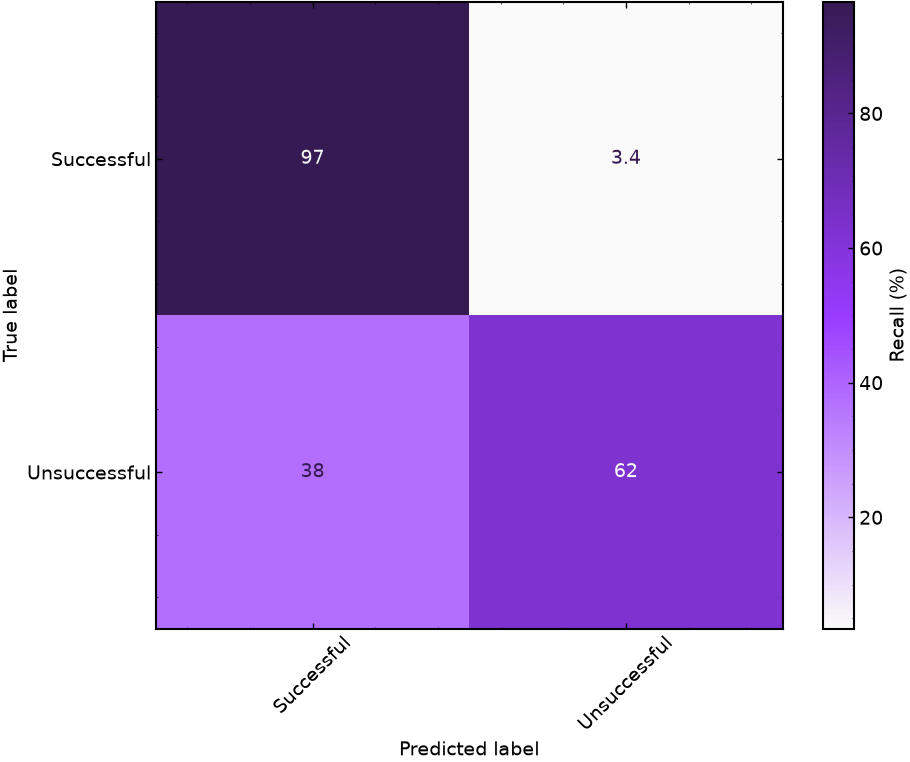

In [17]:
custom_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("custom", ["#fafafa", "#993bff", "#361a54"])
# Normalised version (shows % of each true class correctly predicted)
cm_norm = confusion_matrix(y_test, y_pred_test, normalize='true')
cm_percent = (cm_norm * 100).round(3)  # convert to percentages rounded to 1dp
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=class_labels)
disp.plot(ax=ax, cmap=custom_cmap, colorbar=True, xticks_rotation=45)
disp.im_.colorbar.set_label('Recall (%)')
plt.tight_layout()
plt.show()

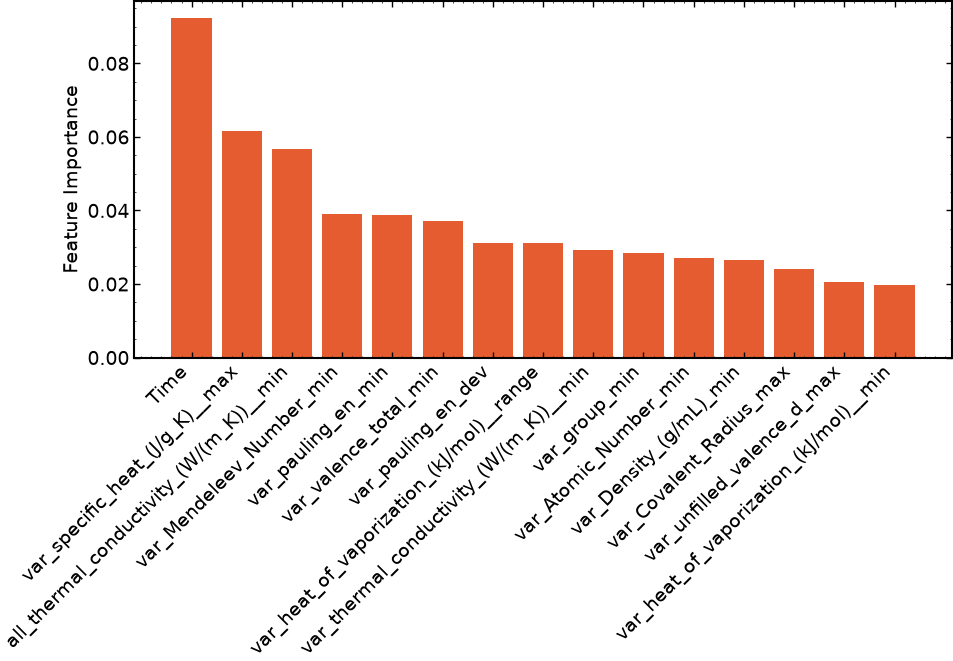

In [18]:
def plot_feature_importances(model, feature_names, top_n=None):
    if not hasattr(model, "feature_importances_"):
        raise ValueError(f"Model type {type(model)} does not have feature_importances_.")
    
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    if top_n is not None:
        indices = indices[:top_n]
    
    plt.figure(figsize=(10, 7))
    plt.bar(range(len(indices)), importances[indices], color = '#e55c30')
    plt.xticks(range(len(indices)), np.array(feature_names)[indices], rotation=45, ha="right")
    plt.ylabel("Feature Importance")
    plt.tight_layout()
    plt.show()

plot_feature_importances(model, feature_cols, top_n = 15)